In [7]:
api_key = api_key = "YOUR_FRED_API_KEY"
start_date = "2026-01-01"
end_date = "2026-03-01"
series = series = [
        (1 / 12, "DGS1MO"),
        (3 / 12, "DGS3MO"),
        (6 / 12, "DGS6MO"),
        (1.0, "DGS1"),
        (2.0, "DGS2"),
        (3.0, "DGS3"),
        (5.0, "DGS5"),
        (7.0, "DGS7"),
        (10.0, "DGS10"),
        (20.0, "DGS20"),
        (30.0, "DGS30")
    ]

In [131]:
import requests
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline
import pandas as pd
from sklearn.decomposition import PCA
import itertools

In [10]:
def fetch_fred_rates(series_id, api_key, start_date, end_date):
    # date should be in yyyy-mm-dd format
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "observation_start": start_date,
        "observation_end": end_date
    }

    response = requests.get(url, params)
    df = pd.DataFrame.from_dict(response.json()['observations'])
    df.drop(columns = ['realtime_start', 'realtime_end'], inplace = True)
    df.dropna(axis = 0, inplace = True)
    df = df[df['value'] != '.']
    df.set_index('date', inplace = True)
    df.index = pd.to_datetime(df.index)
    df['value'] = df['value'].astype(float)
    return df

In [13]:
def fetch_treasury_rates(series, api_key, start_date, end_date):
    # date should be in yyyy-mm-dd format
    rates = pd.DataFrame()
    for t, s_id in series:
        r = fetch_fred_rates(s_id, api_key, start_date, end_date)
        r.rename(columns = {"value": t}, inplace = True)
        rates = pd.concat([rates, r], axis = 1)
    rates.sort_index(inplace = True)
    rates.dropna(inplace = True)
    return rates

In [19]:
class RatesData:
    def __init__(self, rates_pct):
        self.rates_pct = rates_pct
        self.rates_decimal = self.rates_pct/100
        
        self.dates = np.array(rates_pct.index)
        self.tenors = np.array(rates_pct.columns)
        self.latest_date = self.dates[-1]

        self.daily_changes_bp = self.rates_pct.diff().dropna()*100

    def get_curve(self, date, units = 'pct'):
        if date == None:
            date = self.latest_date

        if date not in self.dates:
            raise ValueError("Invalid Date")
            
        if units == "decimal":
            return self.rates_decimal.loc[date]
        elif units == "pct":
            return self.rates_pct.loc[date]
        else:
            raise ValueError("Invalid unit")

        

In [196]:
def show_curve(rates_data, date):
    # Extracts (and plots) curve for a particular date
    curve = rates_data.get_curve(date)
    tenors = rates_data.tenors
    yields = np.array(curve)

    cs = CubicSpline(tenors, yields)

    tenor_grid = np.linspace(tenors.min(), tenors.max(), 300)
    fitted_yields = cs(tenor_grid)
            
    plt.figure(figsize=(8, 5))
    plt.plot(tenor_grid, fitted_yields, label="Cubic spline fit", linewidth=2)
    plt.scatter(tenors, yields, color="red", label="Observed DGS points", zorder=3)
    plt.xlabel("Maturity (years)")
    plt.ylabel("Yield (%)")
    plt.title(f"Treasury Yield Curve - {date}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [45]:
rates_pct = fetch_treasury_rates(series, api_key, '2026-01-01', '2026-03-31')
rates_pct
rates_data = RatesData(rates_pct)

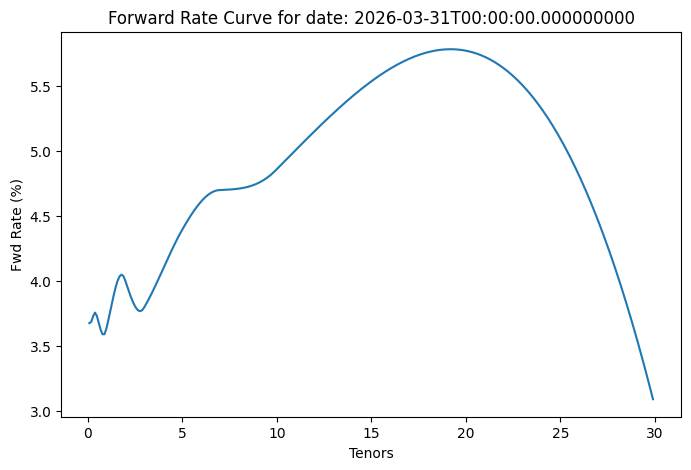

In [83]:
## Cubic Spline Forward-Rate Diagnostics
yields = rates_data.get_curve(rates_data.latest_date, "pct")
tenors = rates_data.tenors
cs = CubicSpline(tenors, yields)

tenor_grid = np.linspace(tenors.min(), tenors.max(), 300)
fitted_yields = cs(tenor_grid)

ty = tenor_grid*fitted_yields
tenor_delta = tenor_grid[1] - tenor_grid[0]
ty_delta = np.diff(ty)
fwd_rate = ty_delta/tenor_delta

plt.figure(figsize=(8, 5))
plt.plot(tenor_grid[:-1], fwd_rate)
plt.xlabel('Tenors')
plt.ylabel('Fwd Rate (%)')
dt = rates_data.latest_date
plt.title('Forward Rate Curve for date: {0}'.format(rates_data.latest_date))
plt.show()

In [157]:
## NSS Calibration 
g = np.linspace(np.log(0.2), np.log(30), 100)
grid = itertools.product(g, g)
rmse_min = np.inf
beta_best = None
tau_best = None
for m1, m2 in grid:
    tau1, tau2 = np.exp(m1), np.exp(m2)
    X0 = np.ones(tenors.shape)
    X1 = (1 - np.exp(-1*tenors/tau1))/(tenors/tau1)
    X2 = (1 - np.exp(-1*tenors/tau1))/(tenors/tau1) - np.exp(-1*tenors/tau1)
    X3 = (1 - np.exp(-1*tenors/tau2))/(tenors/tau2) - np.exp(-1*tenors/tau2)
    # X Shape: (n_tenors, n_factors)
    X = np.column_stack([X0, X1, X2, X3]) # NSS Loading Matrix
    
    beta = np.linalg.lstsq(X, yields, rcond=None)[0]
    fitted = X@beta
    rmse = np.sqrt(np.mean((yields - fitted)**2))
    if rmse < rmse_min:
        rmse_min = rmse
        beta_best = beta
        tau_best = np.array([tau1, tau2])

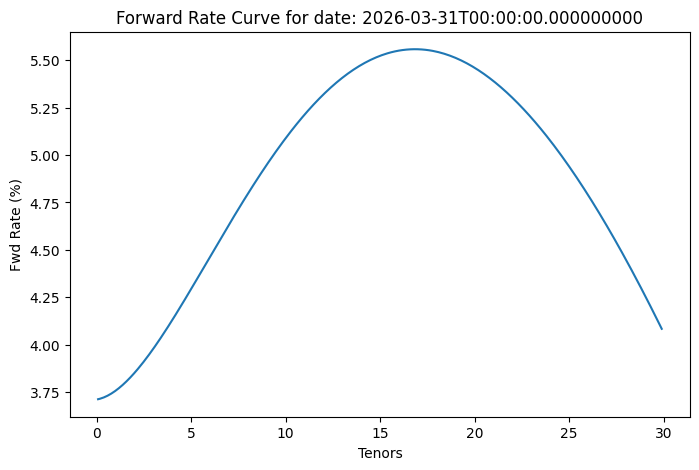

In [167]:
# NSS Forward Rate Diagnostics
tau1, tau2 = tau_best
tenor_grid = np.linspace(tenors.min(), tenors.max(), 300)
X0 = np.ones(tenor_grid.shape)
X1 = (1 - np.exp(-1*tenor_grid/tau1))/(tenor_grid/tau1)
X2 = (1 - np.exp(-1*tenor_grid/tau1))/(tenor_grid/tau1) - np.exp(-1*tenor_grid/tau1)
X3 = (1 - np.exp(-1*tenor_grid/tau2))/(tenor_grid/tau2) - np.exp(-1*tenor_grid/tau2)
# X Shape: (n_tenors, n_factors)
X = np.column_stack([X0, X1, X2, X3]) # NSS Loading Matrix
fitted_yields = X@beta_best

ty = tenor_grid*fitted_yields
tenor_delta = tenor_grid[1] - tenor_grid[0]
ty_delta = np.diff(ty)
fwd_rate = ty_delta/tenor_delta

plt.figure(figsize=(8, 5))
plt.plot(tenor_grid[:-1], fwd_rate)
plt.xlabel('Tenors')
plt.ylabel('Fwd Rate (%)')
dt = rates_data.latest_date
plt.title('Forward Rate Curve for date: {0}'.format(rates_data.latest_date))
plt.show()

In [161]:
beta_best

array([-16.55693084,  20.26710841,  37.37456147,  -4.95545959])

In [163]:
tau_best

array([30.        ,  8.90397598])

In [129]:
for x, y in P:
    print(x, y)

1 1
1 2
1 3
2 1
2 2
2 3
3 1
3 2
3 3


In [153]:
np.exp(10)

22026.465794806718